# Results: Data & Calibration Paradigm

This notebook documents the dataset, the event-flow construction, the preprocessing pipeline, and the calibration quantities used for the Queue-Reactive analysis on Euro-Bund futures.

The presentation follows the structure of Section 3.1 in the paper, but all statistics and figures are computed from our reconstructed Eurex FGBL dataset and the current QR feature pipeline.

In [1]:
from collections import defaultdict
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.features.qr_empirical as qr_empirical
import src.features.qr_transforms as qr_transforms

importlib.reload(qr_empirical)
importlib.reload(qr_transforms)

from src.features.qr_empirical import trading_days
from src.features.qr_transforms import prepare_theta_dataset


In [2]:
QR_PATH = ROOT / "data/processed/FGBL_qr_features.parquet"
RAW_DIR = ROOT / "data/raw"
dataset = ds.dataset(str(QR_PATH), format="parquet")
days = trading_days(str(RAW_DIR))

cols = [
    "ts",
    "date",
    "side",
    "level",
    "eta",
    "q_before",
    "size",
    "delta_t",
    "best_bid_int",
    "best_ask_int",
    "spread_ticks",
    "depletion",
    "depletion_side",
    "p_mid",
    "p_ref",
    "p_ref_empirical",
    "p_ref_fixed",
    "q_before_aes",
    "period_id",
]

event_counts = defaultdict(int)
event_type_counts = defaultdict(int)
size_sums = defaultdict(float)
ait_counts = defaultdict(int)
ait_sums = defaultdict(float)
level_counts = defaultdict(int)
level_type_counts = defaultdict(int)
hour_counts = defaultdict(int)
spread_counts = defaultdict(int)
theta_stats = {1: {"total": 0, "cont": 0}, 5: {"total": 0, "cont": 0}, 10: {"total": 0, "cont": 0}}
theta_micro = {1: {"total": 0, "cont": 0}, 5: {"total": 0, "cont": 0}, 10: {"total": 0, "cont": 0}}
daily_counts = []
period_rows = []
dt_samples = []
queue_sample = None

total_events = 0
best_ordering_ok = True
negative_spreads = 0
depletion_events = 0
p_ref_empirical_diff = 0
p_ref_fixed_diff = 0

def theta_counts(df, horizon, min_next_dt=None):
    theta_df = prepare_theta_dataset(df, min_next_dt=min_next_dt)
    dep_mask = theta_df["depletion"].fillna(False)
    if dep_mask.sum() == 0:
        return 0, 0
    p_mid_h = theta_df["p_mid"].shift(-horizon)
    valid = theta_df.loc[dep_mask, ["p_mid", "depletion_side"]].copy()
    valid["p_mid_horizon"] = p_mid_h.loc[dep_mask]
    valid = valid.dropna(subset=["p_mid_horizon"])
    if valid.empty:
        return 0, 0
    cont = (
        ((valid["depletion_side"] == "ask") & (valid["p_mid_horizon"] > valid["p_mid"]))
        | ((valid["depletion_side"] == "bid") & (valid["p_mid_horizon"] < valid["p_mid"]))
    )
    return len(valid), int(cont.sum())

for day in days:
    table = dataset.to_table(columns=cols, filter=ds.field("date") == day)
    df_day = table.to_pandas()
    if "ts" not in df_day.columns:
        df_day = df_day.reset_index()
    df_day["ts"] = pd.to_datetime(df_day["ts"])
    df_day = df_day.sort_values("ts").set_index("ts")

    n_day = len(df_day)
    total_events += n_day
    daily_counts.append({"date": pd.Timestamp(day), "events": n_day})
    depletion_events += int(df_day["depletion"].fillna(False).sum())

    best_ordering_ok &= bool((df_day["best_bid_int"] < df_day["best_ask_int"]).all())
    negative_spreads += int((df_day["spread_ticks"] <= 0).sum())
    p_ref_empirical_diff += int((~np.isclose(df_day["p_ref_empirical"], df_day["p_mid"], atol=1e-12)).sum())
    p_ref_fixed_diff += int((~np.isclose(df_day["p_ref_fixed"], df_day["p_mid"], atol=1e-12)).sum())

    if queue_sample is None:
        queue_sample = df_day[["q_before", "q_before_aes"]].sample(n=min(50000, len(df_day)), random_state=0)

    positive_dt = df_day.loc[df_day["delta_t"] > 0, "delta_t"]
    if not positive_dt.empty:
        dt_samples.append(positive_dt.sample(n=min(5000, len(positive_dt)), random_state=0))

    grp = df_day.groupby(["side", "level"], sort=False)
    event_grp = grp.size()
    for key, count in event_grp.items():
        event_counts[key] += int(count)
    aes_grp = grp["size"].sum()
    for key, value in aes_grp.items():
        size_sums[key] += float(value)
    ait_grp = df_day.loc[df_day["delta_t"] > 0].groupby(["side", "level"])["delta_t"].agg(["sum", "count"])
    for key, row in ait_grp.iterrows():
        ait_sums[key] += float(row["sum"])
        ait_counts[key] += int(row["count"])

    eta_grp = df_day.groupby(["side", "level", "eta"]).size()
    for key, count in eta_grp.items():
        event_type_counts[key] += int(count)

    level_grp = df_day.groupby("level").size()
    for level, count in level_grp.items():
        level_counts[int(level)] += int(count)

    level_eta_grp = df_day.groupby(["level", "eta"]).size()
    for key, count in level_eta_grp.items():
        level_type_counts[(int(key[0]), str(key[1]))] += int(count)

    hourly = df_day.groupby(df_day.index.hour).size()
    for hour, count in hourly.items():
        hour_counts[int(hour)] += int(count)

    spread_grp = df_day.groupby("spread_ticks").size()
    for spread, count in spread_grp.items():
        spread_counts[int(spread)] += int(count)

    theta_input = df_day[["depletion", "depletion_side", "p_mid", "spread_ticks"]].copy()
    for k in [1, 5, 10]:
        total_k, cont_k = theta_counts(theta_input, horizon=k)
        theta_stats[k]["total"] += total_k
        theta_stats[k]["cont"] += cont_k
        total_m, cont_m = theta_counts(theta_input, horizon=k, min_next_dt=pd.Timedelta("0.5ms"))
        theta_micro[k]["total"] += total_m
        theta_micro[k]["cont"] += cont_m

    period_rows.append(
        {
            "date": pd.Timestamp(day),
            "n_periods": df_day["period_id"].nunique(),
            "mean_events_per_period": len(df_day) / max(df_day["period_id"].nunique(), 1),
        }
    )

daily_counts_df = pd.DataFrame(daily_counts).sort_values("date")
dt_sample = pd.concat(dt_samples, ignore_index=True) if dt_samples else pd.Series(dtype=float)

desc_rows = []
for side in ["B", "A"]:
    for level in [1, 2, 3, 4, 5]:
        key = (side, level)
        n_events = event_counts.get(key, 0)
        aes = size_sums.get(key, 0.0) / n_events if n_events else np.nan
        ait = ait_sums.get(key, 0.0) / ait_counts.get(key, 1) if ait_counts.get(key, 0) else np.nan
        desc_rows.append(
            {
                "side": "bid" if side == "B" else "ask",
                "level": level,
                "n_events": n_events,
                "n_L": event_type_counts.get((side, level, "L"), 0),
                "n_C": event_type_counts.get((side, level, "C"), 0),
                "n_M": event_type_counts.get((side, level, "M"), 0),
                "AES": aes,
                "AIT": ait,
            }
        )
desc_df = pd.DataFrame(desc_rows)

theta_table = pd.DataFrame(
    [
        {
            "horizon_k": k,
            "theta": theta_stats[k]["cont"] / theta_stats[k]["total"] if theta_stats[k]["total"] else np.nan,
            "N_total": theta_stats[k]["total"],
            "N_continuation": theta_stats[k]["cont"],
            "theta_dt_ge_0_5ms": theta_micro[k]["cont"] / theta_micro[k]["total"] if theta_micro[k]["total"] else np.nan,
            "N_total_dt_ge_0_5ms": theta_micro[k]["total"],
        }
        for k in [1, 5, 10]
    ]
)

sanity_df = pd.DataFrame(
    {
        "check": [
            "best_bid < best_ask always",
            "negative / zero spread rows",
            "depletion events",
            "% p_ref_empirical != p_mid",
            "% p_ref_fixed != p_mid",
        ],
        "value": [
            best_ordering_ok,
            negative_spreads,
            depletion_events,
            100 * p_ref_empirical_diff / total_events,
            100 * p_ref_fixed_diff / total_events,
        ],
    }
)

period_df = pd.DataFrame(period_rows)
spread_df = pd.DataFrame(
    [{"spread_ticks": spread, "count": count} for spread, count in sorted(spread_counts.items())]
)
hour_df = pd.DataFrame(
    [{"hour": hour, "count": count} for hour, count in sorted(hour_counts.items())]
)
level_df = pd.DataFrame(
    [{"level": level, "count": count} for level, count in sorted(level_counts.items())]
)
level_type_df = pd.DataFrame(
    [{"level": level, "eta": eta, "count": count} for (level, eta), count in sorted(level_type_counts.items())]
)


## Data Description

**Instrument:** Euro-Bund Futures (`FGBL`)  
**Exchange:** Eurex  
**Time period:** November 2025 (`2025-11-03` to `2025-11-28`)  
**Trading hours used:** `09:00–18:00`  
**Number of trading days:** computed from the processed month  
**Source used here:** the reconstructed queue-level event flow and QR feature dataset

,metric,value
0,Trading days,20.0
1,Total events,6745412.0
2,Average events / day,337270.6
3,Median events / day,303432.5


,date,events
0,2025-11-03,303969
1,2025-11-04,300650
2,2025-11-05,105765
3,2025-11-06,564756
4,2025-11-07,588244
5,2025-11-10,41704
6,2025-11-11,302896
7,2025-11-12,217628
8,2025-11-13,137450
9,2025-11-14,494533


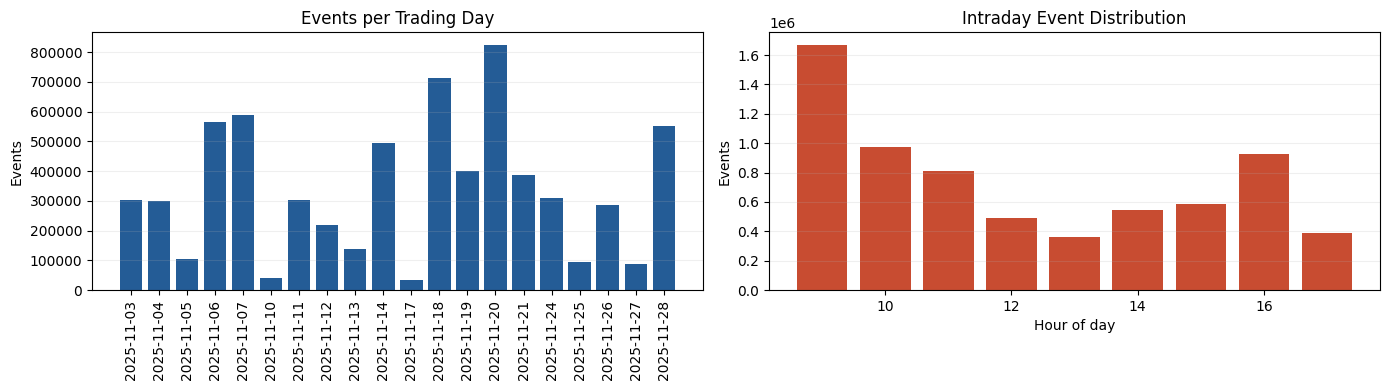

In [3]:
data_summary = pd.DataFrame(
    {
        "metric": ["Trading days", "Total events", "Average events / day", "Median events / day"],
        "value": [
            len(days),
            total_events,
            daily_counts_df["events"].mean(),
            daily_counts_df["events"].median(),
        ],
    }
)
display(data_summary)
display(daily_counts_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(daily_counts_df["date"].dt.strftime("%Y-%m-%d"), daily_counts_df["events"], color="#245c96")
axes[0].set_title("Events per Trading Day")
axes[0].set_ylabel("Events")
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(hour_df["hour"], hour_df["count"], color="#c84c31")
axes[1].set_title("Intraday Event Distribution")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Events")
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()


## Order Flow Construction

The raw LOB updates are converted into a queue-level event flow that records the state of each queue immediately before the event and the type of queue update applied.

Conceptually:
- **`L`**: a limit-order event adds liquidity to a queue
- **`C`**: a cancel event removes resting liquidity from a queue
- **`M`**: a market / trade event removes liquidity from the passive side of the book

The reconstruction logic enforces a valid order book at each step, keeps the top levels ordered, and emits events at the queue level rather than at the message level. In that sense, the event flow is already the calibrated object for the QR model: it is a sequence of queue states and queue updates.

## Table 1: Descriptive Statistics per Level

The table below reports the main descriptive statistics by side and level. AES is the average event size, and AIT is the average **positive** inter-event time using the timestamp-corrected `delta_t`.

,side,level,n_events,n_L,n_C,n_M,AES,AIT
0,bid,1,"770,486","375,259","363,032","32,195",8.04,0.931891
1,bid,2,"711,277","347,157","337,692","26,428",7.81,1.050619
2,bid,3,"685,331","334,052","325,331","25,948",7.99,1.096085
3,bid,4,"664,772","323,509","314,398","26,865",8.15,1.200174
4,bid,5,"614,955","299,148","291,935","23,872",8.26,1.294072
5,ask,1,"598,232","290,135","274,090","34,007",8.49,1.121400
6,ask,2,"604,079","293,523","281,964","28,592",7.90,1.164168
7,ask,3,"664,010","321,356","309,054","33,600",8.21,1.050878
8,ask,4,"721,155","349,663","336,496","34,996",8.67,0.982287
9,ask,5,"711,115","345,220","334,719","31,176",8.37,1.068839


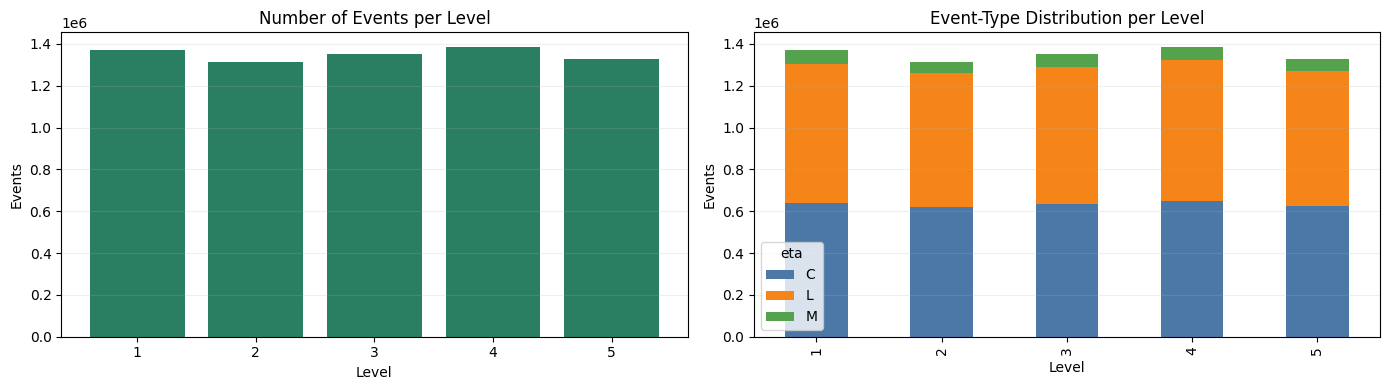

In [4]:
display(
    desc_df.style.format(
        {
            "n_events": "{:,.0f}",
            "n_L": "{:,.0f}",
            "n_C": "{:,.0f}",
            "n_M": "{:,.0f}",
            "AES": "{:.2f}",
            "AIT": "{:.6f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(level_df["level"], level_df["count"], color="#2a7f62")
axes[0].set_title("Number of Events per Level")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Events")
axes[0].grid(axis="y", alpha=0.2)

level_mix = level_type_df.pivot(index="level", columns="eta", values="count").fillna(0)
level_mix.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c78a8", "#f58518", "#54a24b"])
axes[1].set_title("Event-Type Distribution per Level")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Events")
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(title="eta")
fig.tight_layout()


## Preprocessing

### 1. Queue normalization (AES)
Queue sizes are normalized by the average event size at each `(side, level)` and mapped to AES units as

$$ q \leftarrow \left\lceil \frac{q}{AES} \right\rceil. $$

### 2. Reference price (`p_ref`)
The QR pipeline constructs a reference price around the mid-price. In our implementation both the empirical `theta` and the fixed benchmark `theta = 0.7` are available, which makes it possible to compare the data-driven reference-price dynamics against the canonical value from the literature.

### 3. Period segmentation
The data are segmented into periods of constant `p_ref`. The inter-event clock is reset whenever `p_ref` changes, so the calibration is performed inside constant-reference-price periods.

,count,mean,min,25%,50%,75%,max,std
date,20,2025-11-15 12:00:00,2025-11-03 00:00:00,2025-11-09 06:00:00,2025-11-15 12:00:00,2025-11-21 18:00:00,2025-11-28 00:00:00,NaN
n_periods,20.0,2.3,1.0,1.0,2.0,3.0,4.0,1.128576
mean_events_per_period,20.0,169724.079167,20852.0,67412.75,158146.166667,277506.0,412492.5,122513.834789


,check,value
0,best_bid < best_ask always,True
1,negative / zero spread rows,0
2,depletion events,801
3,% p_ref_empirical != p_mid,90.716045
4,% p_ref_fixed != p_mid,99.079048


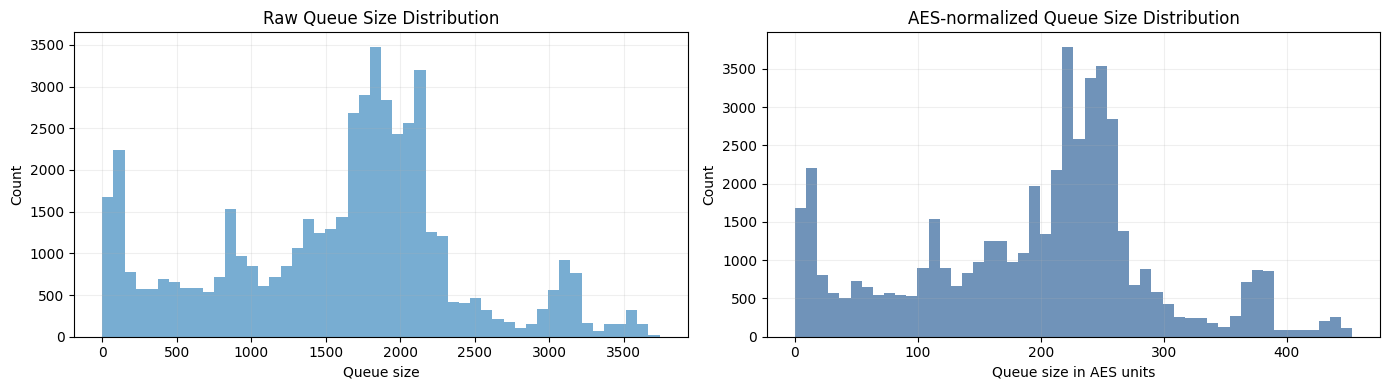

In [5]:
display(period_df.describe().T)
display(sanity_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(queue_sample["q_before"], bins=50, alpha=0.6, label="raw q_before")
axes[0].set_title("Raw Queue Size Distribution")
axes[0].set_xlabel("Queue size")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)

axes[1].hist(queue_sample["q_before_aes"], bins=50, alpha=0.8, color="#4c78a8")
axes[1].set_title("AES-normalized Queue Size Distribution")
axes[1].set_xlabel("Queue size in AES units")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
fig.tight_layout()


## Reference Price Dynamics

The table below reports the empirical calibration of `theta` at several horizons. The additional micro-time filtered column removes depletion rows whose next timestamp arrives within `0.5 ms`.

In [6]:
display(theta_table.style.format({"theta": "{:.4f}", "theta_dt_ge_0_5ms": "{:.4f}", "N_total": "{:,.0f}", "N_continuation": "{:,.0f}", "N_total_dt_ge_0_5ms": "{:,.0f}"}))

theta_interp = f"""
### Interpretation

- The empirical `theta` is estimated directly from the timestamp-corrected queue-depletion process.
- The paper's canonical benchmark is around `0.7`; our Bund estimates can differ because the dataset is strongly large-tick, spread-at-one-tick dominates, and the continuation statistic is sensitive to the microstructure horizon.
"""
display(Markdown(theta_interp))


,horizon_k,theta,N_total,N_continuation,theta_dt_ge_0_5ms,N_total_dt_ge_0_5ms
0,1,0.8525,800,682,0.6557,122
1,5,0.7275,800,582,0.4016,122
2,10,0.6837,800,547,0.4016,122



### Interpretation

- The empirical `theta` is estimated directly from the timestamp-corrected queue-depletion process.
- The paper's canonical benchmark is around `0.7`; our Bund estimates can differ because the dataset is strongly large-tick, spread-at-one-tick dominates, and the continuation statistic is sensitive to the microstructure horizon.


## Inter-event Time Analysis

Inter-event times are heterogeneous across levels. The best levels are expected to update more frequently than deeper queues.

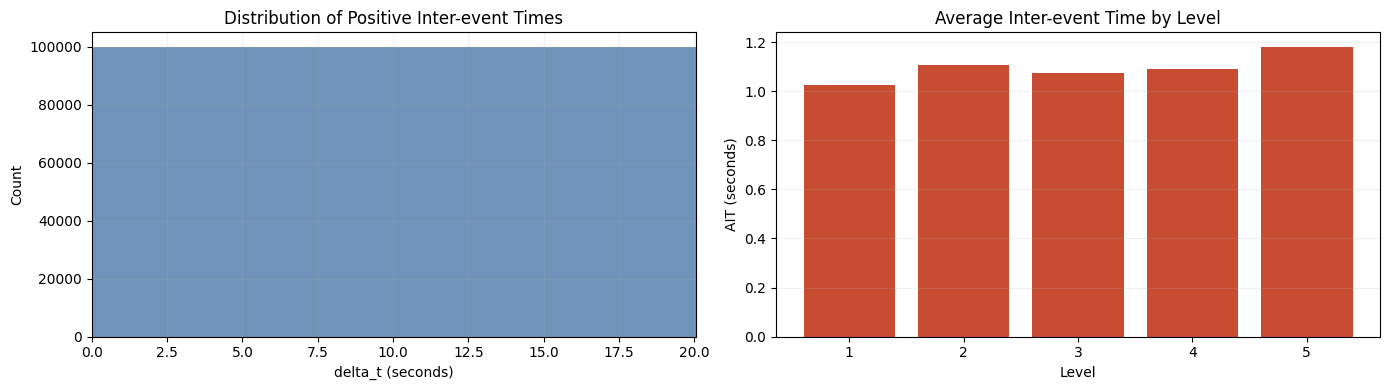

In [7]:
ait_by_level = desc_df.groupby("level")["AIT"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(dt_sample, bins=80, color="#4c78a8", alpha=0.8)
axes[0].set_title("Distribution of Positive Inter-event Times")
axes[0].set_xlabel("delta_t (seconds)")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2)
axes[0].set_xlim(0, np.quantile(dt_sample, 0.99) if len(dt_sample) else 1)

axes[1].bar(ait_by_level["level"], ait_by_level["AIT"], color="#c84c31")
axes[1].set_title("Average Inter-event Time by Level")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("AIT (seconds)")
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()


## Data Quality Checks

The reconstructed event flow should preserve the basic microstructure invariants needed by the QR model.

,check,value
0,best_bid < best_ask always,True
1,negative / zero spread rows,0
2,depletion events,801
3,% p_ref_empirical != p_mid,90.716045
4,% p_ref_fixed != p_mid,99.079048


,spread_ticks,count
0,1,6734611
1,2,9517
2,3,1040
3,4,167
4,5,50
5,6,5
6,7,1
7,217,21


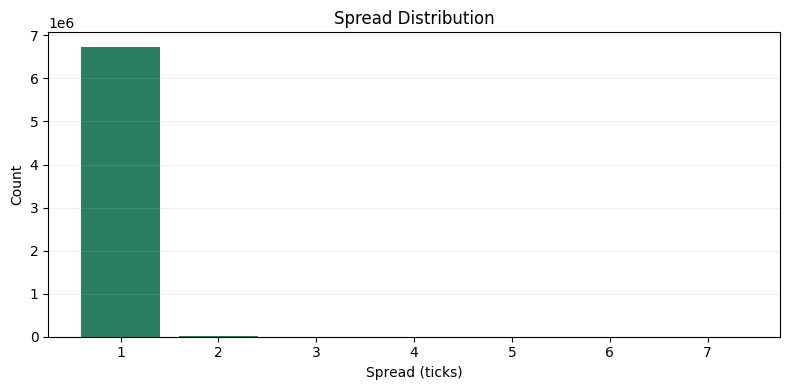

In [8]:
display(sanity_df)
display(spread_df.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
spread_plot = spread_df[spread_df["spread_ticks"] <= 10].copy()
ax.bar(spread_plot["spread_ticks"], spread_plot["count"], color="#2a7f62")
ax.set_title("Spread Distribution")
ax.set_xlabel("Spread (ticks)")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()


## Summary

Bund is a large-tick asset: the spread is dominated by the one-tick state, event activity is concentrated at the best levels, and the queue process evolves on a fast clock at the inside of the book. These properties make the asset a natural candidate for queue-reactive modeling, but they also imply that reference-price moves and depletion-driven continuation dynamics can differ from the more stylized benchmarks in the literature.